<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-04-03 03:09:06--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  42.9MB/s    in 4.8s    

2026-04-03 03:09:14 (41.6 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


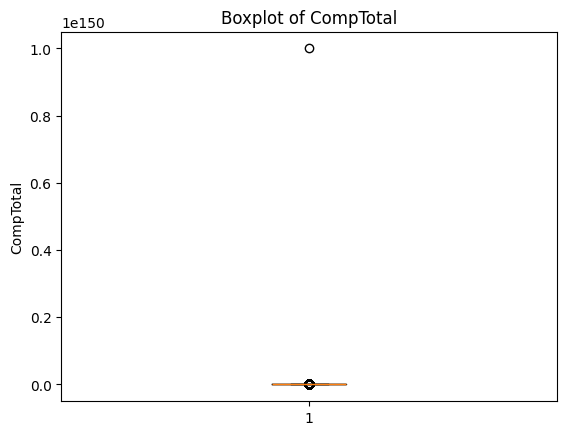

In [11]:
# your code goes here
df_comp = pd.read_sql("SELECT CompTotal FROM main", conn)
df_comp_clean = df_comp
df_comp_clean.dropna(inplace=True)
#df_comp_clean.head(20)

plt.boxplot(df_comp_clean['CompTotal'].dropna())
plt.title('Boxplot of CompTotal')
plt.ylabel('CompTotal')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


                  Age  count  AverAge
0     18-24 years old  14098       21
1     25-34 years old  23911       29
2     35-44 years old  14942       39
3     45-54 years old   6249       49
4     55-64 years old   2575       59
5   65 years or older    772       69
6   Prefer not to say    322        0
7  Under 18 years old   2568       17


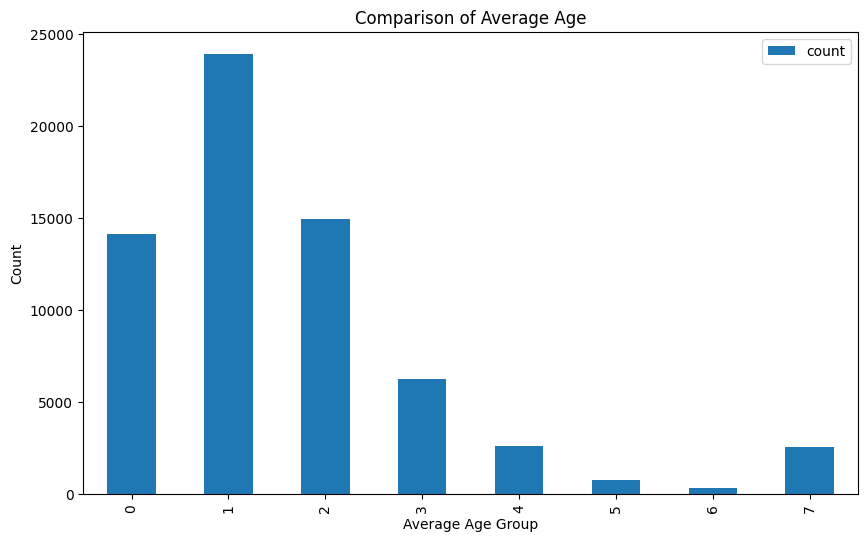

In [27]:
# your code goes here
print(df_age)

#age_mapping = {
#    'Prefer not to say': 0,
#    'Under 18 years old': 17,
#    '18-24 years old': 21,
#    '25-34 years old': 29,
#    '35-44 years old': 39,
#    '45-54 years old': 49,
#    '55-64 years old': 59,
#    '65 years or older': 69
#}

df_age[['count', 'Age']].plot(kind='bar', figsize=(10, 6))

plt.title('Comparison of Average Age')
plt.ylabel('Count')
plt.xlabel('Average Age Group')
plt.show()


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


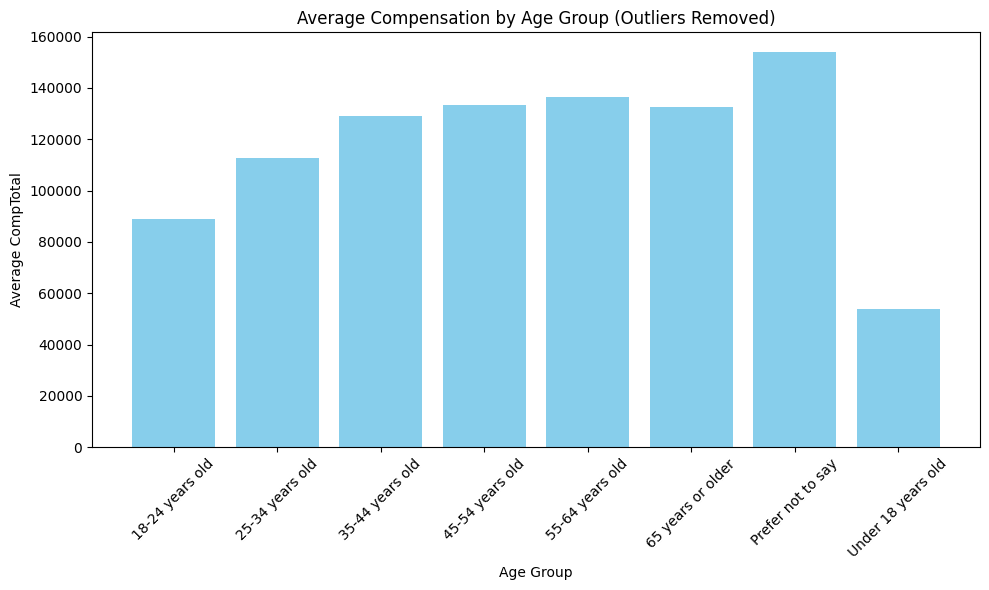

In [33]:
# your code goes here
df_comp_age = pd.read_sql("SELECT CompTotal, Age FROM main", conn)
df_comp_age_clean = df_comp_age
df_comp_age_clean.dropna(inplace=True)
#df_comp_age_clean.head(20)

# 1. Remove outliers from 'CompTotal' using IQR
Q1 = df_comp_age_clean['CompTotal'].quantile(0.25)
Q3 = df_comp_age_clean['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe to keep only rows within the bounds
df_cleaned = df_comp_age_clean[
    (df_comp_age_clean['CompTotal'] >= lower_bound) & 
    (df_comp_age_clean['CompTotal'] <= upper_bound)
].copy()

# 2. Group by 'Age' and find average 'CompTotal'
age_group_avg = df_cleaned.groupby('Age')['CompTotal'].mean().reset_index()

# Sort by age if needed (optional)
# age_group_avg = age_group_avg.sort_values('Age')

# 3. Plot as bar chart
plt.figure(figsize=(10, 6))
plt.bar(age_group_avg['Age'], age_group_avg['CompTotal'], color='skyblue')
plt.xlabel('Age Group')
plt.ylabel('Average CompTotal')
plt.title('Average Compensation by Age Group (Outliers Removed)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


/tmp/ipykernel_4486/3166986878.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_data, labels=labels_present)


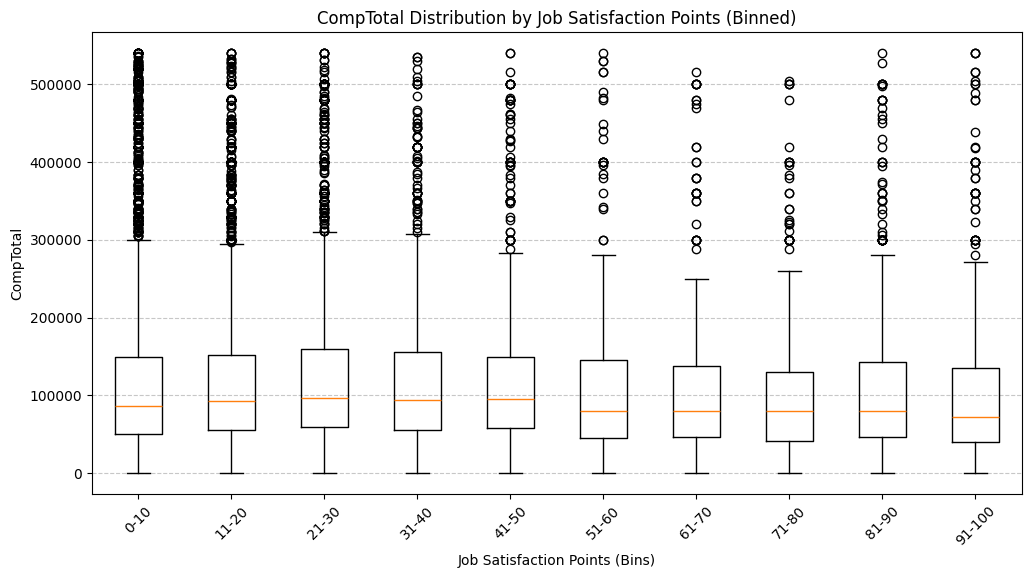

In [55]:
# your code goes here
df_comp_sat6 = pd.read_sql("SELECT CompTotal, JobSatPoints_6 FROM main", conn)

df_comp_sat6_clean = df_comp_sat6
df_comp_sat6_clean.dropna(inplace=True)
#df_comp_sat6.head(20)
#df_comp_sat6_clean.head(20)

df_sat6 = df_comp_sat6_clean.copy()

# 1. Drop outliers in 'CompTotal' column (IQR method)
Q1 = df_comp_sat6_clean['CompTotal'].quantile(0.25)
Q3 = df_comp_sat6_clean['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the dataframe [1, 6, 13]
df_clean = df_comp_sat6_clean[
    (df_comp_sat6_clean['CompTotal'] >= lower_bound) & 
    (df_comp_sat6_clean['CompTotal'] <= upper_bound)
].copy()

# 2. Make bins for 'JobSatPoints_6' by 10 from 0-100
# Assuming 'JobSatPoints_6' is already numerical (0-100)
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', 
          '51-60', '61-70', '71-80', '81-90', '91-100']

df_clean['SatBin'] = pd.cut(df_clean['JobSatPoints_6'], bins=bins, labels=labels, include_lowest=True)

# 3. Box plot 'CompTotal' for each bin using matplotlib
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for plotting
grouped_data = [group['CompTotal'].values for name, group in df_clean.groupby('SatBin')]
labels_present = [name for name, group in df_clean.groupby('SatBin')]

ax.boxplot(grouped_data, labels=labels_present)
ax.set_title('CompTotal Distribution by Job Satisfaction Points (Binned)')
ax.set_xlabel('Job Satisfaction Points (Bins)')
ax.set_ylabel('CompTotal')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


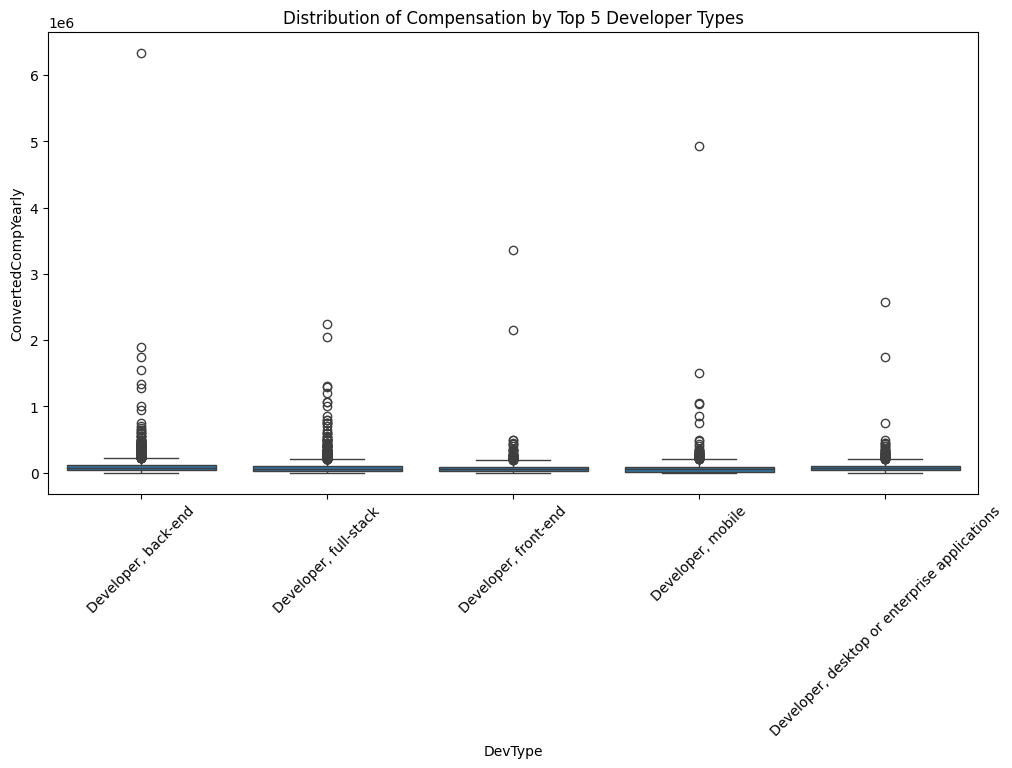

In [70]:
# your code goes here
!pip install seaborn
import seaborn as sns

df_compdev = pd.read_sql("SELECT ConvertedCompYearly, DevType FROM main", conn)
df_compdev_clean = df_compdev.dropna(inplace=True)
df_compdev.head(20)

# 1. Identify Top 5 DevTypes
top5_devs = df_compdev['DevType'].value_counts().nlargest(5).index

# 2. Filter dataframe for Top 5
df_top5 = df_compdev[df_compdev['DevType'].isin(top5_devs)]

# 3. Create Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='DevType', y='ConvertedCompYearly', data=df_top5)
plt.xticks(rotation=45)
plt.title('Distribution of Compensation by Top 5 Developer Types')
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


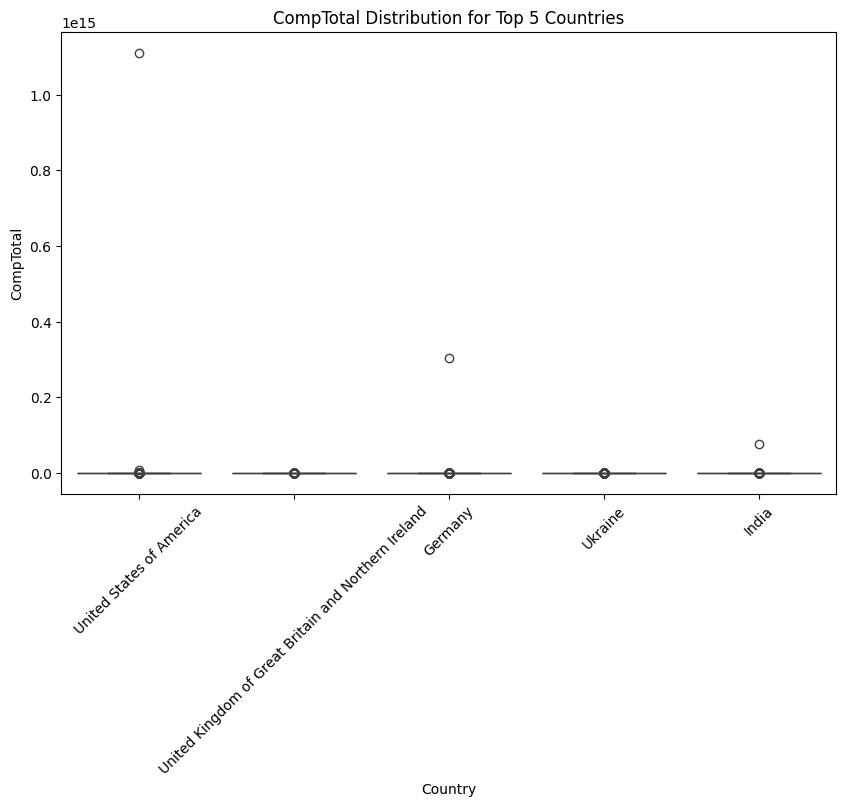

In [73]:
# your code goes here
df_compcountry = pd.read_sql("SELECT CompTotal, Country FROM main", conn)
df_compcountry_clean = df_compcountry.dropna(inplace=True)
df_compcountry.head(20)

# 1. Identify top 5 countries based on frequency
top5_countries = df_compcountry['Country'].value_counts().nlargest(5).index

# 2. Filter dataframe for top 5 countries
df_top5 = df_compcountry[df_compcountry['Country'].isin(top5_countries)]

# 3. Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top5, x='Country', y='CompTotal')
plt.title('CompTotal Distribution for Top 5 Countries')
plt.xticks(rotation=45)
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


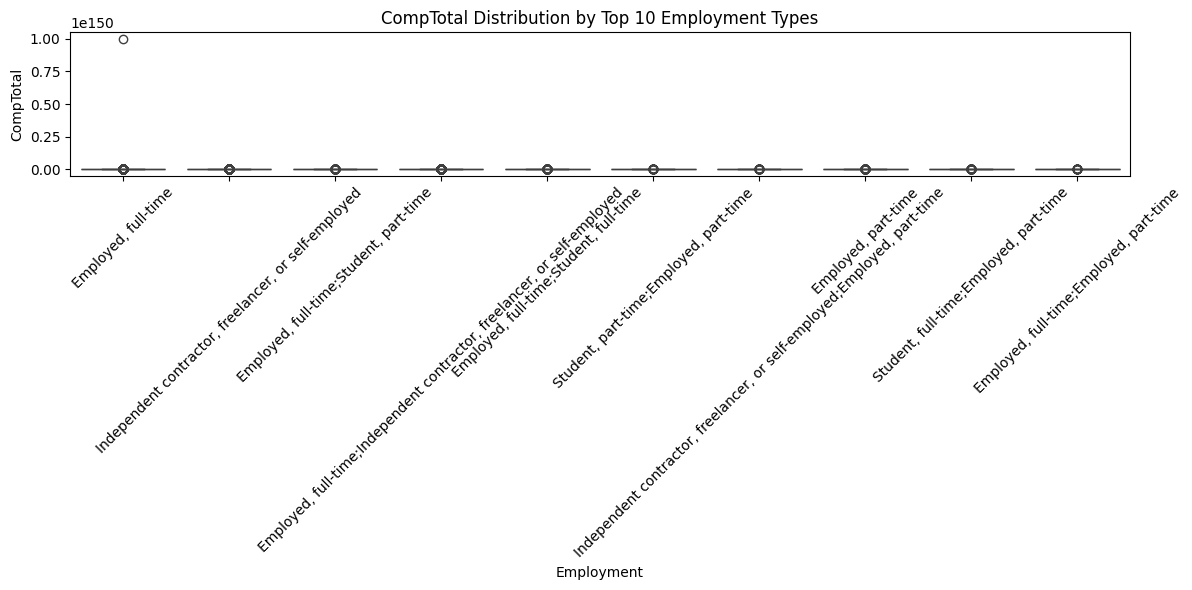

In [77]:
# your code goes here
df_compemploy = pd.read_sql("SELECT CompTotal, Employment FROM main", conn)
df_compemploy_clean = df_compemploy.dropna(inplace=True)
#df_compemploy.head(20)

# 1. Get the names of the top 10 Employment types
top10_employment = df_compemploy['Employment'].value_counts().head(10).index

# 2. Filter the dataframe to only include these top 10
df_top10 = df_compemploy[df_compemploy['Employment'].isin(top10_employment)]

# 3. Create the boxplot
plt.figure(figsize=(12, 6)) # Set figure size for better readability
sns.boxplot(data=df_top10, x='Employment', y='CompTotal')

# 4. Customize plot
plt.xticks(rotation=45) # Rotate labels if they overlap
plt.title('CompTotal Distribution by Top 10 Employment Types')
plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


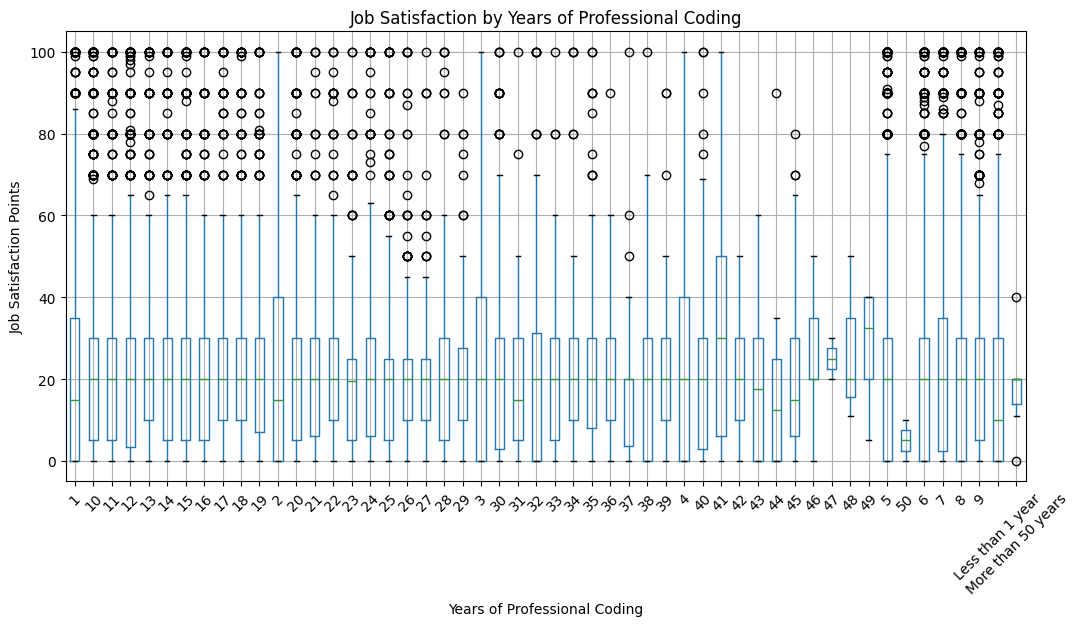

In [83]:
# your code goes here
df_yrssat6 = pd.read_sql("SELECT YearsCodePro, JobSatPoints_6 FROM main", conn)
df_yrssat6_clean = df_yrssat6.dropna(inplace=True)
#df_yrssat6.head(20)

df_yrssat6.boxplot(
    column='JobSatPoints_6', 
    by='YearsCodePro', 
    figsize=(12, 6), 
    rot=45
)

# Customize plot labels and display
plt.title('Job Satisfaction by Years of Professional Coding')
plt.suptitle('') # Removes default pandas title
plt.ylabel('Job Satisfaction Points')
plt.xlabel('Years of Professional Coding')
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [84]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
